# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 96)
        self.enc4 = conv_block(96, 128)
        # Bottleneck
        self.center = conv_block(128, 128)
        self.pool = nn.MaxPool2d(2)


        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, kernel_size=1)
                )
        # 디코더 부분
        self.up4 = upsample_layer(128, 128)
        self.dec4 = conv_block(128 + 128, 96)

        self.up3 = upsample_layer(96, 96)
        self.dec3 = conv_block(96 + 96, 64)

        self.up2 = upsample_layer(64, 64)
        self.dec2 = conv_block(64 + 64, 32)

        self.up1 = upsample_layer(32, 32)
        self.dec1 = conv_block(32 + 32, 16)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        center = self.center(self.pool(e4))

        # 디코더 + Skip Connection
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
         # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [6]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

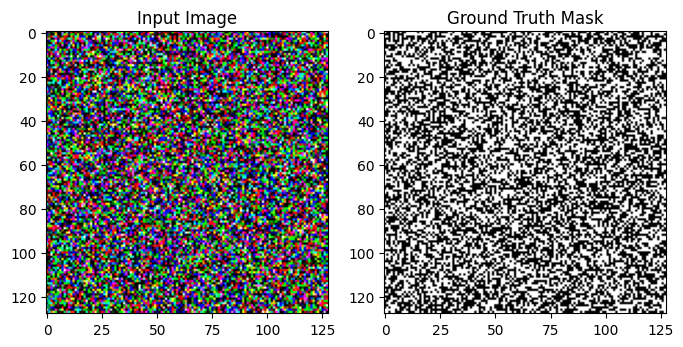

In [7]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [8]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6944
Epoch 2, Loss: 0.6933
Epoch 3, Loss: 0.6932
Epoch 4, Loss: 0.6932
Epoch 5, Loss: 0.6932
Epoch 6, Loss: 0.6931
Epoch 7, Loss: 0.6931
Epoch 8, Loss: 0.6930
Epoch 9, Loss: 0.6930
Epoch 10, Loss: 0.6929


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]


---

- U-Net이란?
  
  U-Net은 주로 이미지 분할(Image Segmentation) 작업에 사용되는 합성곱 신경망(CNN) 기반의 딥러닝 모델이다.
  2015년 바이오메디컬 이미지 세그멘테이션을 위해 처음 제안되었으며, 이후 다양한 분야에서 활용되고 있다.

- 구조 (U자 형태)

  U-Net은 크게 **인코더(Contracting path)**와 디코더(Expanding path) 두 부분으로 구성되며, 가운데 Bridge 또는 Center를 포함한다.

  1. 인코더 (Encoding Path)
  - 일반적인 CNN 구조처럼, 이미지에서 점점 더 추상적인 특징을 추출

  - 연산: Conv → ReLU → Conv → ReLU → MaxPooling

  - 특징: 해상도 ↓, 채널(특징 수) ↑

  2. 디코더 (Decoding Path)
  - 인코더에서 추출된 특징을 바탕으로 다시 원래 해상도로 복원하며, 각 픽셀의 클래스를 예측

  - 연산: UpSampling → Conv → ReLU

  - 특징: 해상도 ↑, 채널 ↓

  3. Skip Connections (스킵 연결)
  - 인코더의 각 단계 출력을 디코더의 대응 단계와 연결 (torch.cat 사용).

  - 이유: 저수준 정보(위치 등)를 보존해 세밀한 분할 가능

  - 장점: 정보 손실 방지 및 학습 안정성 증가


- 주요 특징
  - 입력 크기:	고정 필요 없음 (보통 2의 거듭제곱 권장)
  - 출력 크기:	입력과 동일한 해상도 (픽셀 단위 예측)
  - 사용 분야:	의학 영상, 자율주행, 스타일변환 등
  - 대표 장점: 정확한 경계 추정, 적은 데이터로도 학습 가능

## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

[DeepLab v1]
- CNN 백본 (VGG-16)을 사용

- 마지막 층의 스트라이드 대신 Atrous Convolution을 사용해 해상도 유지

- 이미지 크기를 줄이지 않고 넓은 수용 영역 확보

- Fully Connected CRF (Conditional Random Field)로 출력 경계 세밀화

- 특징 요약
  - 백본:	VGG-16
  - 기술:	Atrous Conv, CRF
  - 장점:	더 높은 해상도로 분할 가능

[DeepLab v2]
- 다양한 크기의 수용영역을 동시에 적용 → 다양한 스케일 특징 추출

- CRF 사용

- V1의 단일 dilation → 여러 dilation rate를 병렬로 적용

- 특징 요약
  - 백본:	ResNet-101
  - 기술:	ASPP, CRF
  - 장점:	멀티 스케일 feature 학습, 정확도 향상

[DeepLab v3]
- CRF 제거 (네트워크 내부에서 경계 복원 가능하도록 구조 개선)

- ASPP 강화: image-level feature 추가 + BatchNorm 적용

- 더 깊은 backbone (ResNet-101 등) 사용 가능

- 특징 요약
  - 백본:	ResNet-101
  - 기술:	개선된 ASPP (멀티레벨 + 글로벌 context)
  - 장점:	외부 CRF 없이 경계 예측 정확도 향상

[DeepLab v3+]
- DeepLab v3 구조를 인코더로, 여기에 디코더를 추가

- 경계 세밀화 및 복원 강화

- Low-level feature (초기 CNN 계층)와 high-level feature 결합

- 특징 요약
  - 백본:	Xception (또는 ResNet)
  - 기술:	DeepLab v3 + Decoder (Upsampling + Skip connection)
  - 장점:	정밀한 경계, 빠른 연산 속도, 효율적 구조